In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import RANSACRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

In [3]:
# 1. Generate synthetic data containing multiple curves
np.random.seed(42)
x1 = np.linspace(-5, 5, 200)
y1 = 0.5 * x1**2 - 2 + np.random.normal(0, 0.5, size=x1.shape) # Curve 1

x2 = np.linspace(-3, 7, 200)
y2 = -0.8 * x2**2 + 3 * x2 + np.random.normal(0, 0.5, size=x2.shape) # Curve 2

# Merge into a single disordered dataset
X = np.concatenate([x1, x2]).reshape(-1, 1)
y = np.concatenate([y1, y2])

In [4]:
# 2. Define the Polynomial Curve Estimator
# We use a pipeline so RANSAC can perform non-linear polynomial regression.
degree = 2  # Set to 2 for quadratic curves, or higher for complex curves
base_estimator = Pipeline([
    ('polynomial_features', PolynomialFeatures(degree=degree)),
    ('linear_regression', LinearRegression())
])

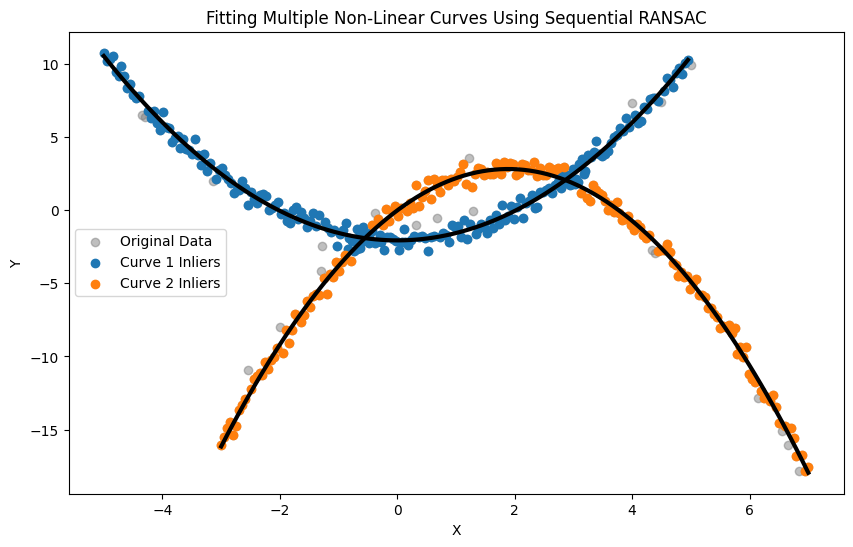

In [5]:
# 3. Sequential RANSAC Loop
X_remaining = X.copy()
y_remaining = y.copy()

detected_curves = []
n_curves_to_find = 2
min_inliers_required = 50 

plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='gray', alpha=0.5, label='Original Data')

for i in range(n_curves_to_find):
    if len(X_remaining) < min_inliers_required:
        print(f"Not enough points left to fit curve {i+1}.")
        break
        
    # Configure the RANSAC Regressor
    ransac = RANSACRegressor(
        estimator=base_estimator,
        min_samples=degree + 2,      # Minimum samples to fit the model shape
        residual_threshold=1.0,     # Maximum distance for a point to be an inlier
        random_state=42
    )
    
    # Fit RANSAC on the remaining data points
    ransac.fit(X_remaining, y_remaining)
    
    # Extract the boolean masks for inside/outside the curve
    inlier_mask = ransac.inlier_mask_
    outlier_mask = ~inlier_mask
    
    # Generate smooth lines for visualization
    x_plot = np.linspace(X_remaining[inlier_mask].min(), X_remaining[inlier_mask].max(), 100).reshape(-1, 1)
    y_plot = ransac.predict(x_plot)
    
    # Plot the discovered curve
    plt.scatter(X_remaining[inlier_mask], y_remaining[inlier_mask], label=f'Curve {i+1} Inliers')
    plt.plot(x_plot, y_plot, linewidth=3, color='black')
    
    # Crucial step: Remove the extracted inliers from the active dataset
    X_remaining = X_remaining[outlier_mask]
    y_remaining = y_remaining[outlier_mask]

plt.title('Fitting Multiple Non-Linear Curves Using Sequential RANSAC')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

In [9]:
ransac.estimator_.

{'memory': None,
 'steps': [('polynomial_features', PolynomialFeatures()),
  ('linear_regression', LinearRegression())],
 'transform_input': None,
 'verbose': False,
 'polynomial_features': PolynomialFeatures(),
 'linear_regression': LinearRegression(),
 'polynomial_features__degree': 2,
 'polynomial_features__include_bias': True,
 'polynomial_features__interaction_only': False,
 'polynomial_features__order': 'C',
 'linear_regression__copy_X': True,
 'linear_regression__fit_intercept': True,
 'linear_regression__n_jobs': None,
 'linear_regression__positive': False,
 'linear_regression__tol': 1e-06}

In [ ]:


def cluster_with_ransac(X, y, n_curves_to_find, degree=2, min_inliers_required=20)
# 2. Define the Polynomial Curve Estimator
# We use a pipeline so RANSAC can perform non-linear polynomial regression.
#degree = 2  # Set to 2 for quadratic curves, or higher for complex curves

base_estimator = Pipeline([
    ('polynomial_features', PolynomialFeatures(degree=degree)),
    ('linear_regression', LinearRegression())
])

# 3. Sequential RANSAC Loop
X_remaining = X.copy()
y_remaining = y.copy()

detected_curves = []
#n_curves_to_find = 2
#min_inliers_required = 50 

X_out = list()
y_out = list()

for i in range(n_curves_to_find):
    if len(X_remaining) < min_inliers_required:
        print(f"Not enough points left to fit curve {i+1}.")
        break
        
    # Configure the RANSAC Regressor
    ransac = RANSACRegressor(
        estimator=base_estimator,
        min_samples=degree + 2,      # Minimum samples to fit the model shape
        residual_threshold=1.0,     # Maximum distance for a point to be an inlier
        random_state=42
    )
    
    # Fit RANSAC on the remaining data points
    ransac.fit(X_remaining, y_remaining)
    
    # Extract the boolean masks for inside/outside the curve
    inlier_mask = ransac.inlier_mask_
    outlier_mask = ~inlier_mask
    
    # Generate smooth lines for visualization
    x_plot = np.linspace(X_remaining[inlier_mask].min(), X_remaining[inlier_mask].max(), 100).reshape(-1, 1)
    y_plot = ransac.predict(x_plot)
    
    # Crucial step: Remove the extracted inliers from the active dataset
    X_remaining = X_remaining[outlier_mask]
    y_remaining = y_remaining[outlier_mask]

plt.title('Fitting Multiple Non-Linear Curves Using Sequential RANSAC')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()